* It is trivial that shifting all images will not affect categorization performance
* Here we will leave the training images as-is, and shift the test images by a few pixels

In [ ]:
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
from sklearn.model_selection import train_test_split

# Data

In [ ]:
data = np.loadtxt(open('/content/sample_data/mnist_train_small.csv', 'rb'), delimiter = ',')

labels = data[:,0]
data = data[:, 1:]

labels = torch.tensor(labels, dtype = torch.long)
data = torch.tensor(data, dtype = torch.float)
data_norm = data / torch.max(data)

labels, data_norm

(tensor([6, 5, 7,  ..., 2, 9, 5]),
 tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]))

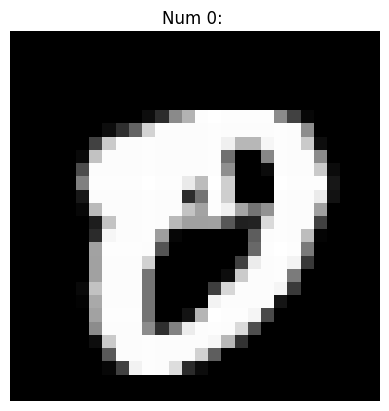

In [ ]:
rand_row = np.random.randint(data.shape[0])
img = np.reshape(data_norm[rand_row], (28,28))
num = labels[rand_row]

plt.imshow(img, cmap = 'grey')
plt.title('Num %d: '%num)
plt.axis(False)
plt.show()

# Split

In [ ]:
train_data, test_data, train_labels, test_labels = train_test_split(data_norm, labels, test_size = .2)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = test_data.shape[0])

# Shift Test Data Only

## Shift the test images by a few pixels

In [ ]:
test_dataloader.dataset.tensors[0]

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

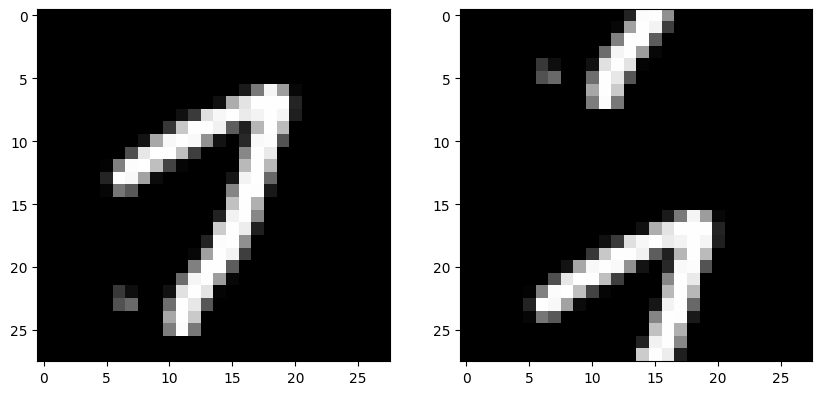

In [ ]:
tmp = test_dataloader.dataset.tensors[0][0,:]
# tmp = test_dataloader.dataset.tensors[0][np.random.randint(test_data.shape[0])]

tmp = tmp.reshape(28,28)

shifted_tmp = torch.roll(tmp, shifts = 10, dims = 0)
fig, ax = plt.subplots(1,2,figsize = (10,5))
ax[0].imshow(tmp, cmap= 'grey')
ax[1].imshow(shifted_tmp, cmap = 'grey')
plt.show()

## Roll every test image

In [ ]:
for i in range(test_dataloader.dataset.tensors[0].shape[0]):
  img_arr = test_dataloader.dataset.tensors[0][i,:]

  randroll = np.random.randint(-11, 10)
  img = np.reshape(img_arr, (28,28))
  img_arr_rl = torch.roll(img, randroll, dims = 1)


  test_dataloader.dataset.tensors[0][i:] = img_arr_rl.reshape(1,-1)

## Model

In [ ]:
def ModelCreate():
  class ModelArch(nn.Module):
    def __init__(self):
      super().__init__()

      self.input = nn.Linear(784, 32)
      self.f1 = nn.Linear(32, 16)
      self.f2 = nn.Linear(16, 16)
      self.output = nn.Linear(16, 10)

    def forward(self, x):
      x = F.relu(self.input(x))
      x = F.relu(self.f1(x))
      x = F.relu(self.f2(x))
      x = self.output(x)
      return x

  ann = ModelArch()
  loss_fn = nn.CrossEntropyLoss()
  optim = torch.optim.SGD(ann.parameters(), lr = 1e-2)

  return ann, loss_fn, optim

In [ ]:
ann, loss_fn, optimizer = ModelCreate()
X, y = next(iter(train_dataloader))
y_hat = ann(X)
loss = loss_fn(y_hat, y)
loss

tensor(2.3175, grad_fn=<NllLossBackward0>)

## Train

In [ ]:
def ModelTrain(epochs, verbose):
  net, loss_fn, optimizer = ModelCreate()

  losses = torch.zeros(epochs)
  train_accs = []
  test_accs = []


  for epoch in range(epochs):
    net.train()

    batch_acc = []
    batch_loss = []


    for X, y in train_dataloader:

      y_hat = net(X)
      loss = loss_fn(y_hat, y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batch_loss.append(loss.item())

      # compute accuracy
      matches = torch.argmax(y_hat, axis = 1) == y
      matches_numeric = matches.float()
      accuracy_pct = 100 * torch.mean(matches_numeric)
      batch_acc.append(accuracy_pct)
    # end of batch loop

    #training accuracy
    train_acc = np.mean(batch_acc)
    train_accs.append(train_acc)

    # and get  avg losses
    losses[epoch] = np.mean(batch_loss)

    # test accuracy
    net.eval()
    X, y = next(iter(test_dataloader))
    with torch.no_grad(): # deactivates autograd
      y_hat = net(X)

    test_acc = 100 * torch.mean((torch.argmax(y_hat, axis = 1) == y).float())
    test_accs.append(test_acc)
  # end epochs

    if verbose and epoch%10 == 0:
      print(f'Epoch: {epoch} | Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f} | Loss: {losses[epoch]:.2f}')

  return train_accs, test_accs, losses

In [ ]:
train_accs, test_accs, losses = ModelTrain(epochs = 100, verbose = True)

Epoch: 0 | Train Acc: 11.23 | Test Acc: 11.15 | Loss: 2.30
Epoch: 10 | Train Acc: 85.03 | Test Acc: 9.90 | Loss: 0.52
Epoch: 20 | Train Acc: 89.74 | Test Acc: 9.85 | Loss: 0.36
Epoch: 30 | Train Acc: 92.59 | Test Acc: 9.57 | Loss: 0.26
Epoch: 40 | Train Acc: 94.34 | Test Acc: 9.30 | Loss: 0.20
Epoch: 50 | Train Acc: 95.59 | Test Acc: 9.25 | Loss: 0.16
Epoch: 60 | Train Acc: 96.56 | Test Acc: 9.12 | Loss: 0.13
Epoch: 70 | Train Acc: 97.22 | Test Acc: 9.43 | Loss: 0.11
Epoch: 80 | Train Acc: 97.64 | Test Acc: 9.30 | Loss: 0.09
Epoch: 90 | Train Acc: 98.37 | Test Acc: 9.70 | Loss: 0.07


## Plot

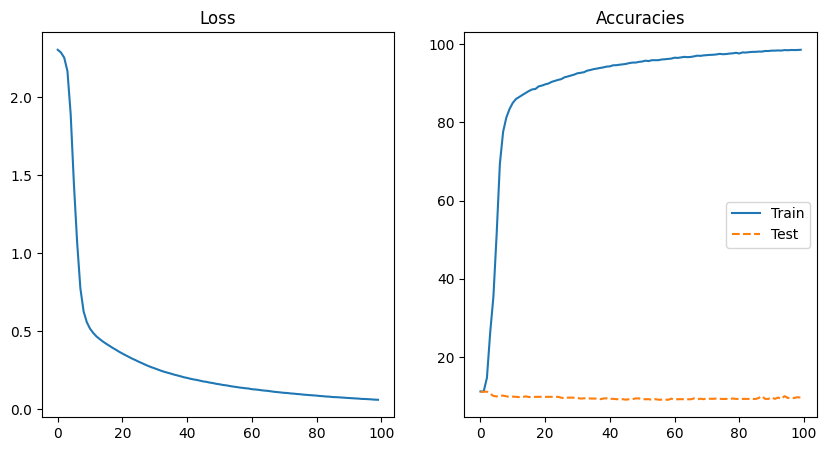

In [ ]:
fig, ax = plt.subplots(1,2,figsize = (10,5))

ax[0].plot(losses)
ax[0].set_title('Loss')

ax[1].plot(train_accs)
ax[1].plot(test_accs, '--')
ax[1].set_title('Accuracies')
ax[1].legend(['Train', 'Test'])

plt.show()

# Assumption

As we can see Test accuracy is horrible. I suppose the reason behind that is our train set (actual train and dev set) are not shifted. That means, during training our model finds patterns between train and dev sets where both are not shifted. Then we introduce test set with different data and model gets lost. Now, we're going to shift Train dataset as well.

# Shift Train Data Additionally

## Shift the train images by a few pixels

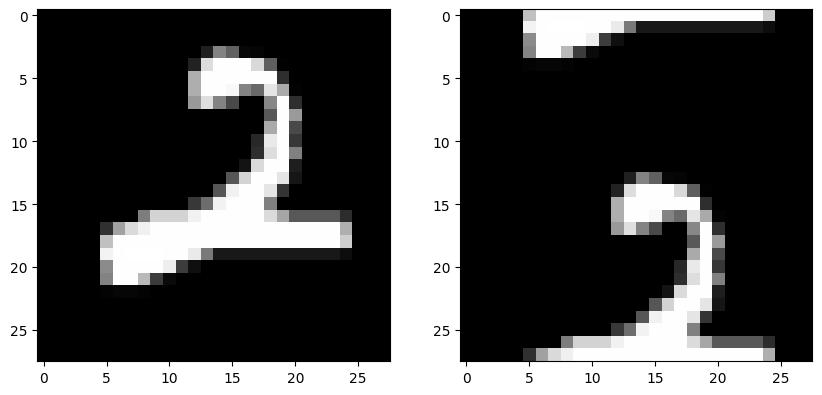

In [ ]:
tmp = train_dataloader.dataset.tensors[0][0,:]

tmp = tmp.reshape(28,28)

shifted_tmp = torch.roll(tmp, shifts = 10, dims = 0)
fig, ax = plt.subplots(1,2,figsize = (10,5))
ax[0].imshow(tmp, cmap= 'grey')
ax[1].imshow(shifted_tmp, cmap = 'grey')
plt.show()

## Roll Every Train Image

In [ ]:
for i in range(train_dataloader.dataset.tensors[0].shape[0]):
  img_arr = train_dataloader.dataset.tensors[0][i,:]

  randroll = np.random.randint(-11, 10)
  img = np.reshape(img_arr, (28,28))
  img_arr_rl = torch.roll(img, randroll, dims = 1)

  train_dataloader.dataset.tensors[0][i:] = img_arr_rl.reshape(1,-1)

## Train

In [ ]:
train_accs, test_accs, losses = ModelTrain(epochs = 100, verbose = True)

Epoch: 0 | Train Acc: 10.06 | Test Acc: 10.23 | Loss: 2.32
Epoch: 10 | Train Acc: 11.23 | Test Acc: 11.15 | Loss: 2.30
Epoch: 20 | Train Acc: 11.23 | Test Acc: 11.15 | Loss: 2.30
Epoch: 30 | Train Acc: 11.23 | Test Acc: 11.15 | Loss: 2.30
Epoch: 40 | Train Acc: 11.16 | Test Acc: 11.15 | Loss: 2.30
Epoch: 50 | Train Acc: 11.17 | Test Acc: 11.15 | Loss: 2.30
Epoch: 60 | Train Acc: 11.38 | Test Acc: 11.15 | Loss: 2.30
Epoch: 70 | Train Acc: 11.30 | Test Acc: 11.15 | Loss: 2.30
Epoch: 80 | Train Acc: 11.34 | Test Acc: 11.15 | Loss: 2.30
Epoch: 90 | Train Acc: 11.34 | Test Acc: 11.15 | Loss: 2.30


## Plot

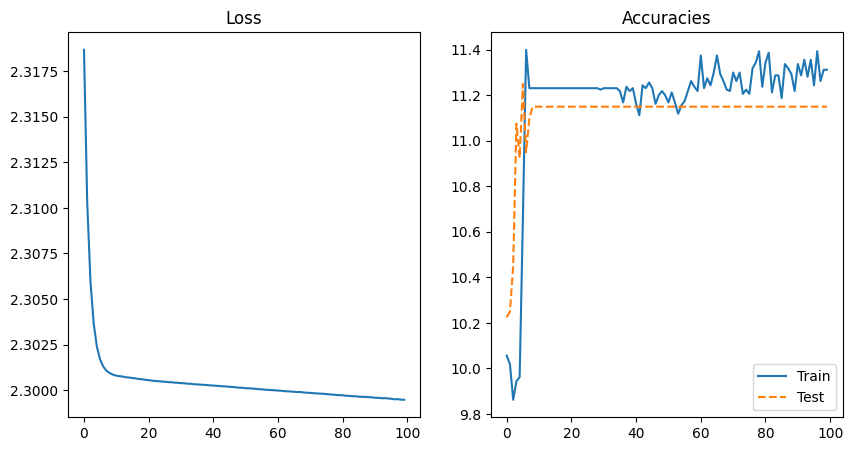

In [ ]:
fig, ax = plt.subplots(1,2,figsize = (10,5))

ax[0].plot(losses)
ax[0].set_title('Loss')

ax[1].plot(train_accs)
ax[1].plot(test_accs, '--')
ax[1].set_title('Accuracies')
ax[1].legend(['Train', 'Test'])

plt.show()

As we can see my assumption about that our test accuracy is due to shifting testing set only was wrong. In above test we shifted train set and test set and as we can see train and test set accuracies are very low. Real reason behind that poor performance is that we're using Feed Forward Networks instead of Convolutional Neural Networks. FFN's are not adjusted for such dynamic actions as shifting what makes them poor choice for computer vision problems. CNN's on the other hand use "scanning technique" which makes possible to see objects more as actual objects and not as static array of floats.

#